In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.insert(1,"../src/")

In [3]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

import acoustic_inversion as ai

from utilities import scramble_nums

In [4]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [156]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [250, 400]

In [159]:
with np.load("../data/output/components_arrival_times.npz", allow_pickle=True ) as file1:
    data_components = dict(mode_nos = file1['mode_nos'].squeeze(), peaks_coordinates=file1['peaks_coordinates'])
data_components['mode_nos'] = data_components['mode_nos'] - 1


with np.load("../data/output/full_arrival_times.npz", allow_pickle=True ) as file1:
    data_full = dict(mode_nos = file1['mode_nos'], peaks_coordinates=file1['peaks_coordinates'])
data_full['mode_nos'] = data_full['mode_nos'] - 1

inds = np.argsort(data_full['mode_nos'])
data_full['mode_nos'] = data_full['mode_nos'][inds]

data_full['peaks_coordinates'] = data_full['peaks_coordinates'][inds]


In [179]:
data_components['mode_nos']

array([ 1,  0,  5,  6,  7,  9,  8, 14, 16])

In [180]:
# in this block, we introduce some perturbation to the mode numbers

data_components['mode_nos'] = scramble_nums(data_components['mode_nos'])
data_full['mode_nos'] = scramble_nums(data_full['mode_nos'])

[-1  0  1]
[0 1]
[-1  0  1]
[0 1]
[-1  1]
[-1  0  1]
[-1  0]
[-1  0  1]
[0 1]
[0 1]
[0 1]
[-1  0  1]
[-1  1]
[-1  0  1]
[-1  0  1]
[-1  0  1]


In [181]:
data_components['mode_nos']

array([ 2,  0,  5,  7,  6,  9,  8, 15, 16])

In [182]:
len(data_components['peaks_coordinates'])

9

In [183]:
replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze().transpose([1,0,2])
#Vg = Vg[data_components['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [184]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [185]:
arrival_times_replica = receiver_range/Vg[...,f_mask]

In [186]:
arrival_times_components = ai.arrival_times_from_peaks(data_components['peaks_coordinates'], regression_f)
arrival_times_full = ai.arrival_times_from_peaks(data_full['peaks_coordinates'], regression_f)

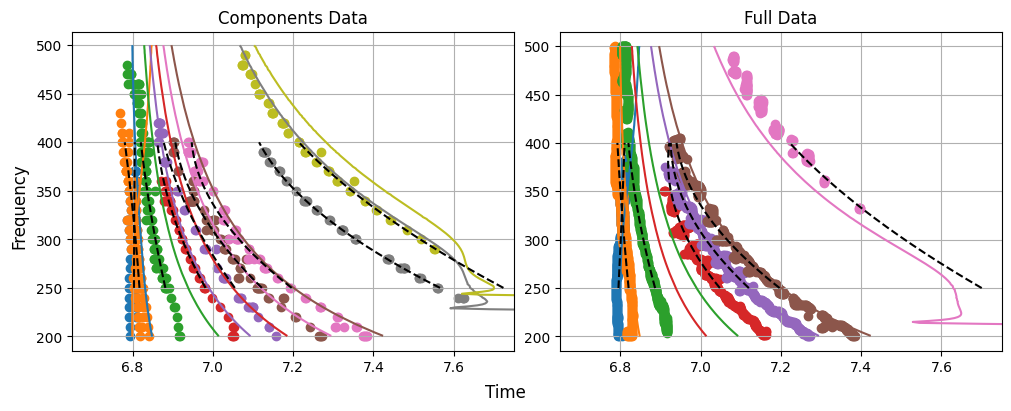

In [187]:
fig, (ax_comp, ax_full) = plt.subplots(1,2, layout="constrained")

for p in data_components['peaks_coordinates']:
    ax_comp.scatter(p[:,1], p[:,0])
    
ax_comp.plot(receiver_range/Vg[c==TRUE_SOUNDSPEED,data_components['mode_nos'],:].T, f_Vg)
ax_comp.set_prop_cycle(None)
ax_comp.plot(arrival_times_components.T, regression_f, ls='--', c='k')

ax_comp.set_xlim([6.65, 7.75])

ax_comp.grid()

ax_comp.set_title("Components Data")

for p in data_full['peaks_coordinates']:
    ax_full.scatter(p[:,1], p[:,0])
    
ax_full.plot(receiver_range/Vg[c==TRUE_SOUNDSPEED,data_full['mode_nos'],:].T, f_Vg)
ax_full.set_prop_cycle(None)
ax_full.plot(arrival_times_full.T, regression_f, ls='--', c='k')

ax_full.set_xlim([6.65, 7.75])

ax_full.grid()

ax_full.set_title("Full Data")


fig.supylabel("Frequency")
fig.supxlabel("Time")

fig.set_size_inches([10, 4])

In [188]:
fig.savefig("../data/output/mode_curves.png", dpi=600)

## Direct dispersion

In [189]:
l_comp = ai.AcousticInversionLikelihood(arrival_times_components)
l_full = ai.AcousticInversionLikelihood(arrival_times_full)

In [190]:
lk_direct_comp = l_comp.likelihood_direct(arrival_times_replica[:,data_components['mode_nos']], 0.5e-1)
lk_direct_full = l_full.likelihood_direct(arrival_times_replica[:,data_full['mode_nos']], 0.5e-1)

(29, 9, 151)
(29, 7, 151)


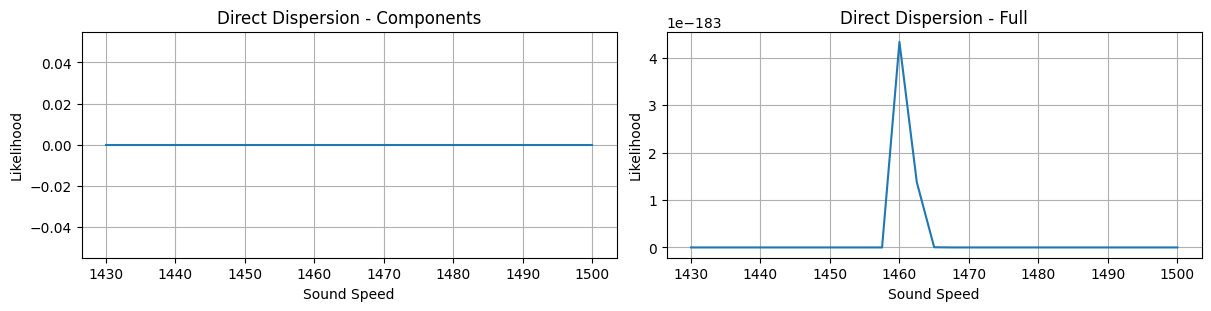

In [191]:
fig, (ax, ax_full) = plt.subplots(1,2, layout="constrained")

ax.plot(c, lk_direct_comp)
ax.grid()

ax.set_title(f'Direct Dispersion - Components')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')



ax_full.plot(c, lk_direct_full)
ax_full.grid()

ax_full.set_title(f'Direct Dispersion - Full')
ax_full.set_xlabel('Sound Speed')
ax_full.set_ylabel('Likelihood')

fig.set_size_inches([12,3])

In [192]:
fig.savefig("../data/output/direct_dispersion.png", dpi=600)

In [193]:
normalize = lambda x: x/np.sum(x)

In [194]:
lk_comp = l_comp.likelihood(arrival_times_replica[:, data_components['mode_nos']], 1e0)
lk_full = l_full.likelihood(arrival_times_replica[:, data_full['mode_nos']], 1e0)

In [195]:
lk_comp = normalize(lk_comp)
lk_full = normalize(lk_full)


Text(0, 0.5, 'Likelihood')

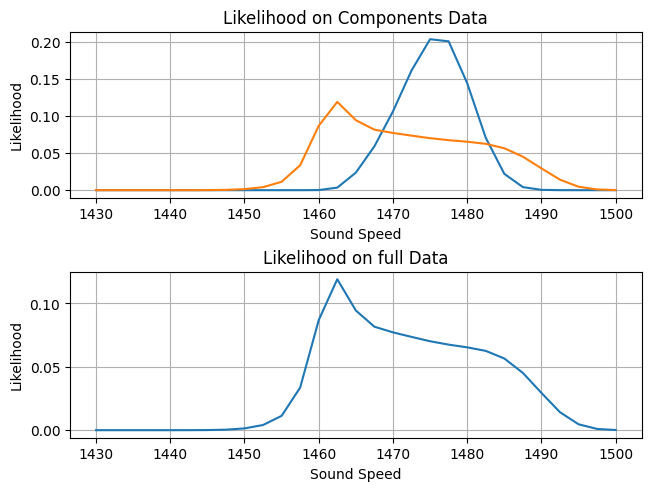

In [196]:
fig, (ax, ax_full) = plt.subplots(2,1, layout="constrained")


ax.plot(c, lk_comp)
ax.plot(c, lk_full)
ax.grid()

ax.set_title("Likelihood on Components Data")

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")


ax_full.plot(c, lk_full)
ax_full.grid()

ax_full.set_title("Likelihood on full Data")

ax_full.set_xlabel("Sound Speed")
ax_full.set_ylabel("Likelihood")

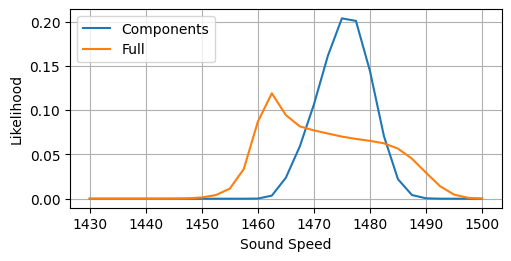

In [197]:
fig, ax = plt.subplots(layout="constrained")


ax.plot(c, lk_comp)
ax.plot(c, lk_full)
ax.grid()

ax.legend(["Components", "Full"])

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")

fig.set_size_inches([5, 2.5])

In [23]:
fig.savefig("../data/output/likelihood_deltas.png", dpi=600)

In [24]:
c = np.array([-1, 0, 1])

In [125]:
data_full['mode_nos']

array([ 0,  1,  4,  7,  8,  9, 15])

In [140]:
scramble_nums(data_full['mode_nos'])

[0 1]
[-1  1]
[-1  0  1]
[-1  0  1]
[0 1]
[0 1]
[-1  0  1]


array([ 1.,  2.,  4.,  7.,  8.,  9., 14.])

In [27]:
np.random.choice(c)

np.int64(1)